In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [66]:
data = {
    "CGPA": [
        6.2, 6.5, 6.8, 7.0, 7.2,
        7.4, 7.5, 7.7, 7.8, 8.0,
        8.1, 8.2, 8.3, 8.4, 8.5,
        8.6, 8.7, 8.8, 8.9, 9.0,
        9.1, 9.2, 9.3, 9.4, 9.5,
        6.3, 6.6, 6.9, 7.1, 7.3,
        7.6, 7.9, 8.05, 8.15, 8.25,
        8.35, 8.45, 8.55, 8.65, 8.75
    ],

    "AptitudeScore": [
        45, 48, 50, 52, 55,
        58, 60, 62, 64, 66,
        68, 70, 72, 74, 76,
        78, 80, 82, 84, 86,
        88, 90, 92, 94, 95,
        47, 51, 54, 56, 59,
        61, 65, 67, 69, 71,
        73, 75, 77, 79, 81
    ],

    "CommunicationScore": [
        48, 50, 52, 54, 55,
        58, 60, 61, 63, 65,
        67, 69, 71, 73, 75,
        77, 79, 81, 83, 85,
        87, 89, 91, 93, 95,
        49, 53, 55, 57, 60,
        62, 64, 66, 68, 70,
        72, 74, 76, 78, 80
    ],

    "Internships": [
        0, 0, 1, 1, 1,
        1, 1, 2, 2, 2,
        2, 2, 2, 2, 2,
        2, 2, 3, 3, 3,
        3, 3, 3, 3, 3,
        0, 1, 1, 1, 1,
        2, 2, 2, 2, 2,
        2, 3, 3, 3, 3
    ],

    "Projects": [
        1, 1, 1, 2, 2,
        2, 2, 2, 3, 3,
        3, 3, 3, 3, 3,
        3, 3, 4, 4, 4,
        4, 4, 4, 4, 4,
        1, 1, 2, 2, 2,
        2, 3, 3, 3, 3,
        3, 3, 4, 4, 4
    ],

    "Department": [
        "CSE", "CSE", "ECE", "ECE", "IT",
        "IT", "CSE", "CSE", "ECE", "IT",
        "CSE", "ECE", "IT", "CSE", "ECE",
        "IT", "CSE", "ECE", "IT", "CSE",
        "ECE", "IT", "CSE", "ECE", "IT",
        "CSE", "ECE", "IT", "CSE", "ECE",
        "IT", "CSE", "ECE", "IT", "CSE",
        "ECE", "IT", "CSE", "ECE", "IT"
    ],

    "Gender": [
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male"
    ]
}

df = pd.DataFrame(data)

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (40, 7)


,CGPA,AptitudeScore,CommunicationScore,Internships,Projects,Department,Gender
0,6.2,45,48,0,1,CSE,Female
1,6.5,48,50,0,1,CSE,Male
2,6.8,50,52,1,1,ECE,Female
3,7.0,52,54,1,2,ECE,Male
4,7.2,55,55,1,2,IT,Female


In [67]:
df["PlacementScore"] = (
    df["CGPA"] * 10
    + df["AptitudeScore"] * 0.35
    + df["CommunicationScore"] * 0.25
    + df["Internships"] * 8
    + df["Projects"] * 4
)

df["PlacementStatus"] = np.where(
    df["PlacementScore"] >= 100,
    "Placed",
    "Not Placed"
)

print("Placement Status:")
print(df["PlacementStatus"].value_counts())

Placement Status:
PlacementStatus
Placed        37
Not Placed     3
Name: count, dtype: int64


In [68]:
feature_cols = [
    "CGPA",
    "AptitudeScore",
    "CommunicationScore",
    "Internships",
    "Projects",
    "Department",
    "Gender"
]

X = df[feature_cols]

y = df["PlacementStatus"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (40, 7)
y shape: (40,)


In [69]:
numeric_features = [
    "CGPA",
    "AptitudeScore",
    "CommunicationScore",
    "Internships",
    "Projects"
]

categorical_features = [
    "Department",
    "Gender"
]

In [70]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("OHE + Scaling preprocessing created.")

OHE + Scaling preprocessing created.


In [71]:
X_train, X_val, y_train, y_val = train_test_split(

    X,
    y,

    test_size=0.25,

    random_state=42,

    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 30
Validation samples: 10


In [72]:
lasso_model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                penalty="l1",
                solver="liblinear",
                C=1.0,
                max_iter=1000
            )
        )
    ]
)

lasso_model.fit(
    X_train,
    y_train
)

lasso_pred = lasso_model.predict(
    X_val
)

print(
    "Lasso Validation Accuracy:",
    accuracy_score(y_val, lasso_pred)
)

Lasso Validation Accuracy: 0.9


In [73]:
def compare_regularisation(
    X_train,
    y_train,
    X_val,
    y_val,
    C_values
):

    results = []

    for C in C_values:

        # ==========================================
        # LASSO - L1
        # ==========================================

        lasso_model = Pipeline(

            steps=[

                (
                    "preprocessor",
                    preprocessor
                ),

                (
                    "classifier",
                    LogisticRegression(
                        penalty="l1",
                        solver="liblinear",
                        C=C,
                        max_iter=1000
                    )
                )
            ]
        )

        lasso_model.fit(
            X_train,
            y_train
        )

        lasso_pred = lasso_model.predict(
            X_val
        )

        lasso_acc = accuracy_score(
            y_val,
            lasso_pred
        )


        # ==========================================
        # RIDGE - L2
        # ==========================================

        ridge_model = Pipeline(

            steps=[

                (
                    "preprocessor",
                    preprocessor
                ),

                (
                    "classifier",
                    LogisticRegression(
                        penalty="l2",
                        solver="lbfgs",
                        C=C,
                        max_iter=1000
                    )
                )
            ]
        )

        ridge_model.fit(
            X_train,
            y_train
        )

        ridge_pred = ridge_model.predict(
            X_val
        )

        ridge_acc = accuracy_score(
            y_val,
            ridge_pred
        )


        # ==========================================
        # ELASTIC NET
        # ==========================================

        elastic_model = Pipeline(

            steps=[

                (
                    "preprocessor",
                    preprocessor
                ),

                (
                    "classifier",
                    LogisticRegression(
                        penalty="elasticnet",
                        solver="saga",
                        C=C,
                        l1_ratio=0.5,
                        max_iter=5000,
                        random_state=42
                    )
                )
            ]
        )

        elastic_model.fit(
            X_train,
            y_train
        )

        elastic_pred = elastic_model.predict(
            X_val
        )

        elastic_acc = accuracy_score(
            y_val,
            elastic_pred
        )


        # ==========================================
        # COUNT NON-ZERO COEFFICIENTS
        # ==========================================

        lasso_coef = (
            lasso_model
            .named_steps["classifier"]
            .coef_[0]
        )

        ridge_coef = (
            ridge_model
            .named_steps["classifier"]
            .coef_[0]
        )

        elastic_coef = (
            elastic_model
            .named_steps["classifier"]
            .coef_[0]
        )


        lasso_nonzero = np.sum(
            np.abs(lasso_coef) > 1e-6
        )

        ridge_nonzero = np.sum(
            np.abs(ridge_coef) > 1e-6
        )

        elastic_nonzero = np.sum(
            np.abs(elastic_coef) > 1e-6
        )


        # ==========================================
        # STORE RESULTS
        # ==========================================

        results.append({

            "C": C,

            "Lasso_val_acc": lasso_acc,

            "Ridge_val_acc": ridge_acc,

            "ElasticNet_val_acc": elastic_acc,

            "Lasso_nonzero": lasso_nonzero,

            "Ridge_nonzero": ridge_nonzero,

            "ElasticNet_nonzero": elastic_nonzero
        })


    # ==========================================
    # RETURN DATAFRAME
    # ==========================================

    results_df = pd.DataFrame(
        results
    )

    return results_df

In [74]:
C_values = [
    0.01,
    0.03,
    0.1,
    0.3,
    1,
    3,
    10,
    30,
    100
]

print("C Values:")
print(C_values)

C Values:
[0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]


In [75]:
results_df = compare_regularisation(

    X_train,
    y_train,

    X_val,
    y_val,

    C_values
)

print("========== REGULARISATION COMPARISON ==========")

display(results_df)

========== REGULARISATION COMPARISON ==========


,C,Lasso_val_acc,Ridge_val_acc,ElasticNet_val_acc,Lasso_nonzero,Ridge_nonzero,ElasticNet_nonzero
0,0.01,0.1,0.9,0.9,0,10,0
1,0.03,0.1,0.9,0.9,0,10,0
2,0.10,0.9,0.9,0.9,0,10,0
3,0.30,0.9,0.9,0.9,1,10,4
4,1.00,0.9,1.0,1.0,1,10,6
5,3.00,1.0,1.0,1.0,2,10,7
6,10.00,1.0,1.0,1.0,3,10,8
7,30.00,1.0,1.0,1.0,3,10,9
8,100.00,1.0,1.0,1.0,3,10,9


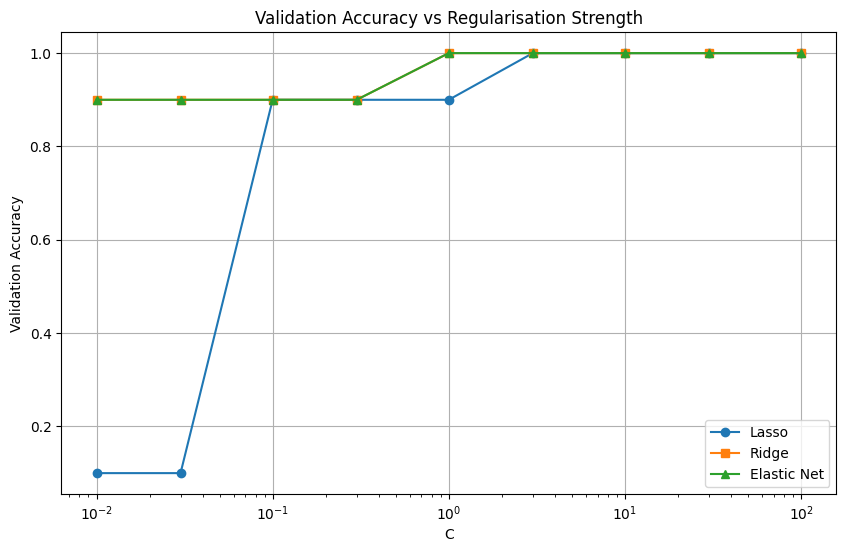

In [76]:
plt.figure(figsize=(10, 6))

plt.semilogx(
    results_df["C"],
    results_df["Lasso_val_acc"],
    marker="o",
    label="Lasso"
)

plt.semilogx(
    results_df["C"],
    results_df["Ridge_val_acc"],
    marker="s",
    label="Ridge"
)

plt.semilogx(
    results_df["C"],
    results_df["ElasticNet_val_acc"],
    marker="^",
    label="Elastic Net"
)

plt.xlabel("C")

plt.ylabel("Validation Accuracy")

plt.title(
    "Validation Accuracy vs Regularisation Strength"
)

plt.legend()

plt.grid(True)

plt.show()

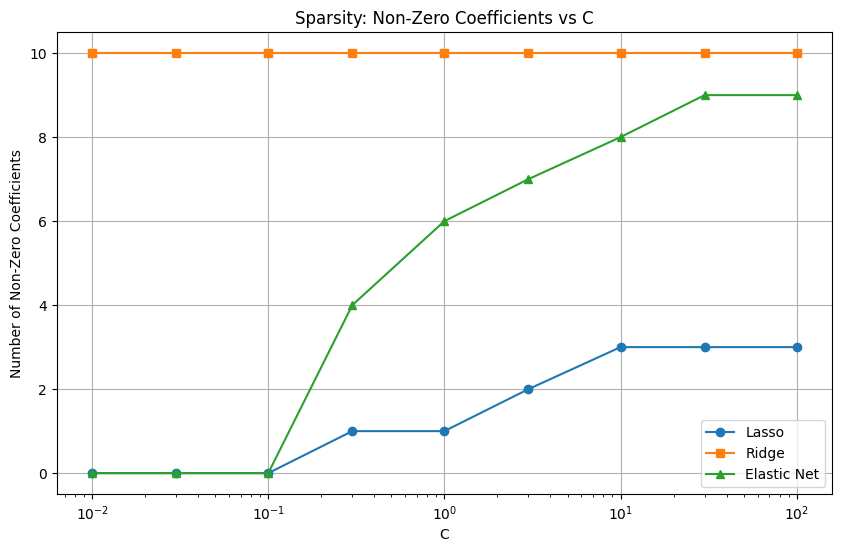

In [77]:
plt.figure(figsize=(10, 6))

plt.semilogx(
    results_df["C"],
    results_df["Lasso_nonzero"],
    marker="o",
    label="Lasso"
)

plt.semilogx(
    results_df["C"],
    results_df["Ridge_nonzero"],
    marker="s",
    label="Ridge"
)

plt.semilogx(
    results_df["C"],
    results_df["ElasticNet_nonzero"],
    marker="^",
    label="Elastic Net"
)

plt.xlabel("C")

plt.ylabel("Number of Non-Zero Coefficients")

plt.title(
    "Sparsity: Non-Zero Coefficients vs C"
)

plt.legend()

plt.grid(True)

plt.show()

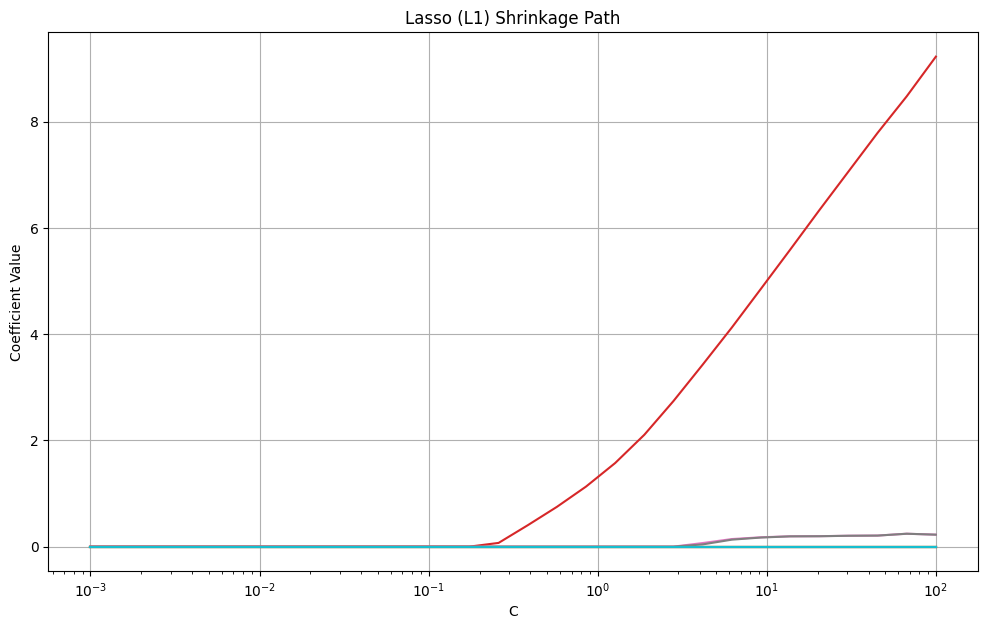

In [78]:
C_path = np.logspace(
    -3,
    2,
    30
)

lasso_coefficients = []

for C in C_path:

    model = Pipeline(

        steps=[

            (
                "preprocessor",
                preprocessor
            ),

            (
                "classifier",
                LogisticRegression(
                    penalty="l1",
                    solver="liblinear",
                    C=C,
                    max_iter=1000
                )
            )
        ]
    )

    model.fit(
        X_train,
        y_train
    )

    coefficients = (
        model
        .named_steps["classifier"]
        .coef_[0]
    )

    lasso_coefficients.append(
        coefficients
    )

lasso_coefficients = np.array(
    lasso_coefficients
)

plt.figure(figsize=(12, 7))

for i in range(
    lasso_coefficients.shape[1]
):

    plt.semilogx(
        C_path,
        lasso_coefficients[:, i]
    )

plt.xlabel("C")

plt.ylabel("Coefficient Value")

plt.title(
    "Lasso (L1) Shrinkage Path"
)

plt.grid(True)

plt.show()

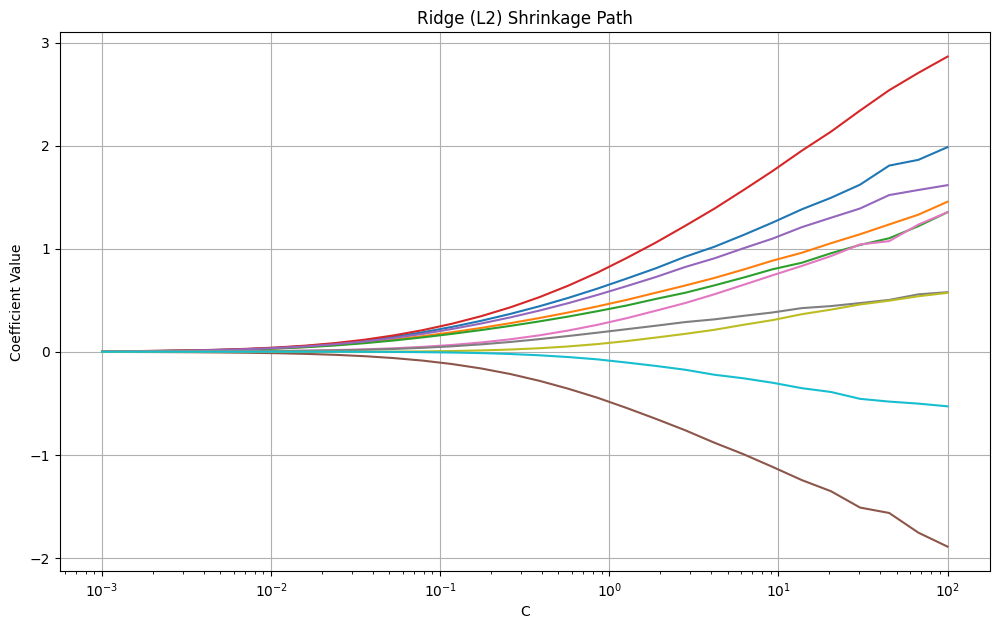

In [79]:
ridge_coefficients = []

for C in C_path:

    model = Pipeline(

        steps=[

            (
                "preprocessor",
                preprocessor
            ),

            (
                "classifier",
                LogisticRegression(
                    penalty="l2",
                    solver="lbfgs",
                    C=C,
                    max_iter=1000
                )
            )
        ]
    )

    model.fit(
        X_train,
        y_train
    )

    coefficients = (
        model
        .named_steps["classifier"]
        .coef_[0]
    )

    ridge_coefficients.append(
        coefficients
    )

ridge_coefficients = np.array(
    ridge_coefficients
)

plt.figure(figsize=(12, 7))

for i in range(
    ridge_coefficients.shape[1]
):

    plt.semilogx(
        C_path,
        ridge_coefficients[:, i]
    )

plt.xlabel("C")

plt.ylabel("Coefficient Value")

plt.title(
    "Ridge (L2) Shrinkage Path"
)

plt.grid(True)

plt.show()

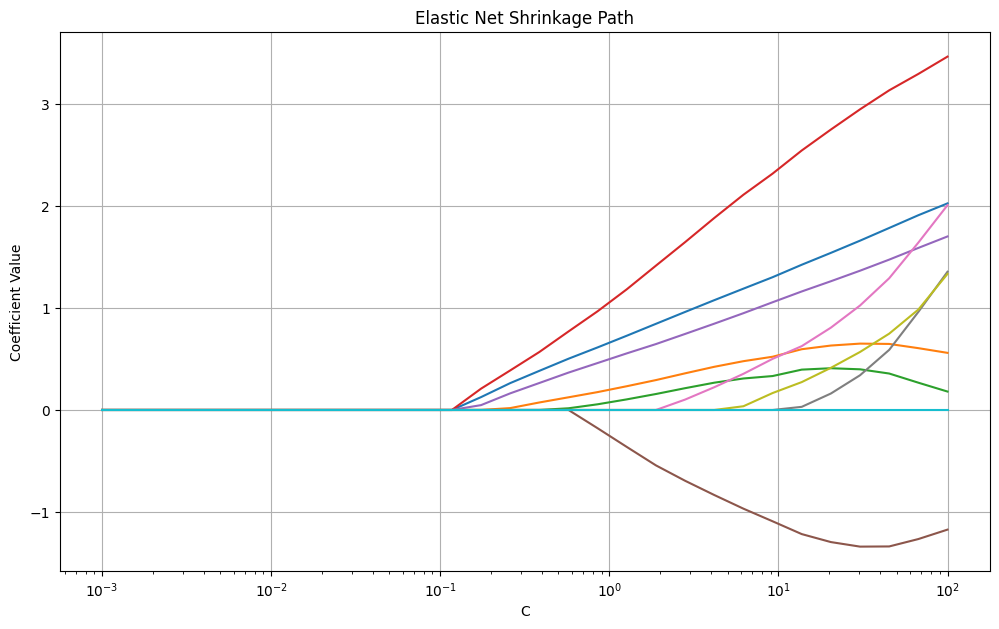

In [80]:
elastic_coefficients = []

for C in C_path:

    model = Pipeline(

        steps=[

            (
                "preprocessor",
                preprocessor
            ),

            (
                "classifier",
                LogisticRegression(
                    penalty="elasticnet",
                    solver="saga",
                    C=C,
                    l1_ratio=0.5,
                    max_iter=5000,
                    random_state=42
                )
            )
        ]
    )

    model.fit(
        X_train,
        y_train
    )

    coefficients = (
        model
        .named_steps["classifier"]
        .coef_[0]
    )

    elastic_coefficients.append(
        coefficients
    )

elastic_coefficients = np.array(
    elastic_coefficients
)

plt.figure(figsize=(12, 7))

for i in range(
    elastic_coefficients.shape[1]
):

    plt.semilogx(
        C_path,
        elastic_coefficients[:, i]
    )

plt.xlabel("C")

plt.ylabel("Coefficient Value")

plt.title(
    "Elastic Net Shrinkage Path"
)

plt.grid(True)

plt.show()

In [81]:
print("========== NON-ZERO COEFFICIENT COMPARISON ==========")

display(
    results_df[
        [
            "C",
            "Lasso_nonzero",
            "Ridge_nonzero",
            "ElasticNet_nonzero"
        ]
    ]
)

========== NON-ZERO COEFFICIENT COMPARISON ==========


,C,Lasso_nonzero,Ridge_nonzero,ElasticNet_nonzero
0,0.01,0,10,0
1,0.03,0,10,0
2,0.10,0,10,0
3,0.30,1,10,4
4,1.00,1,10,6
5,3.00,2,10,7
6,10.00,3,10,8
7,30.00,3,10,9
8,100.00,3,10,9


In [82]:
print("========== VALIDATION ACCURACY COMPARISON ==========")

display(
    results_df[
        [
            "C",
            "Lasso_val_acc",
            "Ridge_val_acc",
            "ElasticNet_val_acc"
        ]
    ]
)

========== VALIDATION ACCURACY COMPARISON ==========


,C,Lasso_val_acc,Ridge_val_acc,ElasticNet_val_acc
0,0.01,0.1,0.9,0.9
1,0.03,0.1,0.9,0.9
2,0.10,0.9,0.9,0.9
3,0.30,0.9,0.9,0.9
4,1.00,0.9,1.0,1.0
5,3.00,1.0,1.0,1.0
6,10.00,1.0,1.0,1.0
7,30.00,1.0,1.0,1.0
8,100.00,1.0,1.0,1.0


In [83]:
C_final = 1.0

# ==============================
# LASSO
# ==============================

lasso_final = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=C_final,
        max_iter=1000
    ))
])

lasso_final.fit(X_train, y_train)
lasso_pred = lasso_final.predict(X_val)

print("========== LASSO ==========")
print(classification_report(
    y_val,
    lasso_pred,
    zero_division=0
))


# ==============================
# RIDGE
# ==============================

ridge_final = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=C_final,
        max_iter=1000
    ))
])

ridge_final.fit(X_train, y_train)
ridge_pred = ridge_final.predict(X_val)

print("========== RIDGE ==========")
print(classification_report(
    y_val,
    ridge_pred,
    zero_division=0
))


# ==============================
# ELASTIC NET
# ==============================

elastic_final = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        C=C_final,
        l1_ratio=0.5,
        max_iter=5000,
        random_state=42
    ))
])

elastic_final.fit(X_train, y_train)
elastic_pred = elastic_final.predict(X_val)

print("========== ELASTIC NET ==========")
print(classification_report(
    y_val,
    elastic_pred,
    zero_division=0
))

========== LASSO ==========
              precision    recall  f1-score   support

  Not Placed       0.00      0.00      0.00         1
      Placed       0.90      1.00      0.95         9

    accuracy                           0.90        10
   macro avg       0.45      0.50      0.47        10
weighted avg       0.81      0.90      0.85        10

========== RIDGE ==========
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00         1
      Placed       1.00      1.00      1.00         9

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

========== ELASTIC NET ==========
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00         1
      Placed       1.00      1.00      1.00         9

    accuracy                           1.00        10
   macro avg       1.00      1.00     

In [84]:
ridge_final = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                C=C_final,
                max_iter=1000
            )
        )
    ]
)

ridge_final.fit(
    X_train,
    y_train
)

ridge_pred = ridge_final.predict(
    X_val
)

print("========== RIDGE CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_val,
        ridge_pred,
        zero_division=0
    )
)

========== RIDGE CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00         1
      Placed       1.00      1.00      1.00         9

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [85]:
elastic_final = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                C=C_final,
                l1_ratio=0.5,
                max_iter=5000,
                random_state=42
            )
        )
    ]
)

elastic_final.fit(
    X_train,
    y_train
)

elastic_pred = elastic_final.predict(
    X_val
)

print("========== ELASTIC NET CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_val,
        elastic_pred,
        zero_division=0
    )
)

========== ELASTIC NET CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00         1
      Placed       1.00      1.00      1.00         9

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [86]:
final_summary = pd.DataFrame({

    "Model": [
        "Lasso",
        "Ridge",
        "Elastic Net"
    ],

    "Validation Accuracy": [
        accuracy_score(
            y_val,
            lasso_pred
        ),

        accuracy_score(
            y_val,
            ridge_pred
        ),

        accuracy_score(
            y_val,
            elastic_pred
        )
    ],

    "Non-Zero Coefficients": [

        np.sum(
            np.abs(
                lasso_final
                .named_steps["classifier"]
                .coef_[0]
            ) > 1e-6
        ),

        np.sum(
            np.abs(
                ridge_final
                .named_steps["classifier"]
                .coef_[0]
            ) > 1e-6
        ),

        np.sum(
            np.abs(
                elastic_final
                .named_steps["classifier"]
                .coef_[0]
            ) > 1e-6
        )
    ]
})

print("========== FINAL SUMMARY ==========")

display(final_summary)

========== FINAL SUMMARY ==========


,Model,Validation Accuracy,Non-Zero Coefficients
0,Lasso,0.9,1
1,Ridge,1.0,10
2,Elastic Net,1.0,6
